## Measure FPS & Latency

In [1]:
import numpy as np
import time
from carla_adapter import CarlaAdapter
from ultralytics import YOLO

def benchmark(model, adapter, seconds=10, conf=0.25, iou=0.45):
    latencies = []
    frames = 0
    start = time.perf_counter()

    while (time.perf_counter() - start) < seconds:
        frame = adapter.get_frame()
        if frame is None:
            continue

        t0 = time.perf_counter()
        _ = model.predict(frame, conf=conf, iou=iou, verbose=False)
        t1 = time.perf_counter()

        latencies.append((t1 - t0) * 1000)  # ms
        frames += 1

    total = time.perf_counter() - start
    fps = frames / total if total > 0 else 0

    return {
        "frames": frames,
        "seconds": total,
        "fps": fps,
        "latency_ms_mean": float(np.mean(latencies)) if latencies else None,
        "latency_ms_p95": float(np.percentile(latencies, 95)) if latencies else None,
    }

model = YOLO('research/models/weights/best.pt')
adapter = CarlaAdapter(autopilot=True, image_width=640, image_height=360)
adapter.start()

try:
    stats = benchmark(model, adapter, seconds=10, conf=0.25, iou=0.45)
    print("\n=== YOLOv8 Performance Benchmark ===")
    print(f"Model: {model.model_name if hasattr(model, 'model_name') else 'custom weights'}")
    print(f"Resolution: 640x360")
    print(f"Confidence threshold: 0.25")
    print(f"IoU threshold: 0.45")
    print("----------------------------------")
    print(f"Total frames processed : {stats['frames']}")
    print(f"Test duration (s)       : {stats['seconds']:.2f}")
    print(f"Effective FPS           : {stats['fps']:.2f}")
    print(f"Mean latency (ms)       : {stats['latency_ms_mean']:.2f}")
    print(f"95th percentile (ms)    : {stats['latency_ms_p95']:.2f}")
    print("==================================\n")
finally:
    adapter.stop()



=== YOLOv8 Performance Benchmark ===
Model: research/models/weights/best.pt
Resolution: 640x360
Confidence threshold: 0.25
IoU threshold: 0.45
----------------------------------
Total frames processed : 152
Test duration (s)       : 10.07
Effective FPS           : 15.10
Mean latency (ms)       : 65.97
95th percentile (ms)    : 69.80



## Confidence Tuning & IOU thresholds

In [3]:
import pandas as pd

confs = [0.15, 0.25, 0.35, 0.5]
ious = [0.4, 0.45, 0.5]

rows = []
adapter = CarlaAdapter(autopilot=True, image_width=640, image_height=360)
adapter.start()

try:
    for c in confs:
        for i in ious:
            stats = benchmark(model, adapter, seconds=6, conf=c, iou=i)
            rows.append({"conf": c, "iou": i, **stats})
finally:
    adapter.stop()

df = pd.DataFrame(rows)
df


,conf,iou,frames,seconds,fps,latency_ms_mean,latency_ms_p95
0,0.15,0.40,90,6.040460,14.899527,66.726351,70.424940
1,0.15,0.45,95,6.027812,15.760280,63.411660,68.162390
2,0.15,0.50,94,6.051672,15.532897,64.340173,68.960975
3,0.25,0.40,88,6.044046,14.559783,68.642914,75.949320
4,0.25,0.45,83,6.040212,13.741239,72.734075,75.535250
5,0.25,0.50,83,6.020829,13.785478,72.500648,75.997100
6,0.35,0.40,83,6.001506,13.829861,72.267622,75.037520
7,0.35,0.45,83,6.010818,13.808437,72.379192,74.930210
8,0.35,0.50,83,6.034626,13.753958,72.667794,75.448700
9,0.50,0.40,83,6.002370,13.827872,72.276671,74.915200


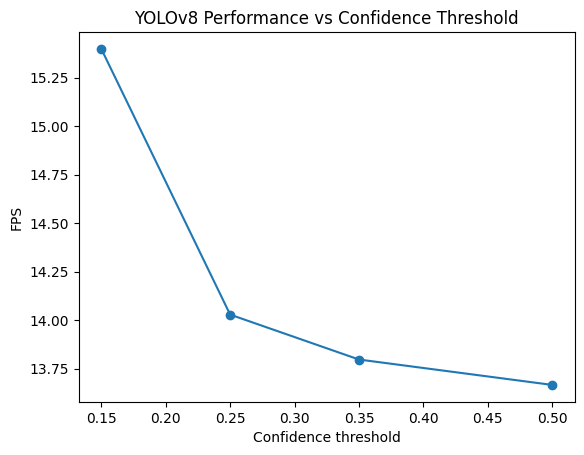

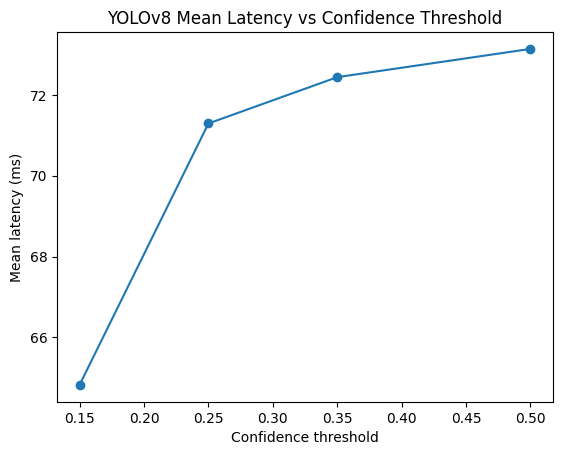

In [4]:
import matplotlib.pyplot as plt

# example: average FPS per conf across IOUs
fps_by_conf = df.groupby("conf")["fps"].mean()

plt.figure()
plt.plot(fps_by_conf.index, fps_by_conf.values, marker="o")
plt.xlabel("Confidence threshold")
plt.ylabel("FPS")
plt.title("YOLOv8 Performance vs Confidence Threshold")
plt.show()

lat_by_conf = df.groupby("conf")["latency_ms_mean"].mean()

plt.figure()
plt.plot(lat_by_conf.index, lat_by_conf.values, marker="o")
plt.xlabel("Confidence threshold")
plt.ylabel("Mean latency (ms)")
plt.title("YOLOv8 Mean Latency vs Confidence Threshold")
plt.show()
